Objective:

Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight charges, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.

Manual invoice review is time-consuming and does not scale with increasing transaction volume.
Abnormal freight charges, unusual pricing deviations, or delivery delays may indicate errors, disputes, fraud, or compliance risks.
An automated flagging system helps finance teams focus on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  mean_absolute_error, mean_squared_error , r2_score, accuracy_score ,classification_report
from sklearn.model_selection import GridSearchCV
from scipy.stats import ttest_ind

In [2]:
conn =sqlite3.connect("inventory.db")
tables = pd.read_sql_query("Select name from sqlite_master where type ='table'" , conn )

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
for table in tables['name']:
     print('Table name', table)
     df = pd.read_sql_query(f"Select * from {table} limit 5 ",conn)
     display(df)
  

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [5]:
purchase_agg_df =  pd.read_sql_query("""
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate))
        AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
""", conn)

In [6]:
purchase_agg_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [7]:
pd.read_sql_query( """
Select 
 vi.PONumber,
 vi.Quantity as total_invoice_quantity ,
 vi.Dollars as total_invoice_dollars,
 vi.freight, 
 (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_to_gen_invoice,
 (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay
 From vendor_invoice vi
 """,
 conn)

,PONumber,total_invoice_quantity,total_invoice_dollars,Freight,days_to_gen_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [8]:
merged_df = pd.read_sql_query("""
SELECT
    vi.PONumber,

    -- Vendor invoice information
    vi.Quantity AS total_invoice_quantity,
    vi.Dollars AS total_invoice_dollars,
    vi.Freight,

    (julianday(vi.InvoiceDate) - julianday(vi.PODate))
        AS days_to_gen_invoice,

    (julianday(vi.PayDate) - julianday(vi.InvoiceDate))
        AS days_to_pay,

    -- Purchase information
    p.total_brands,
    p.total_item_quantity,
    p.total_item_dollars,
    p.avg_receiving_delay

FROM vendor_invoice vi

LEFT JOIN (
    SELECT
        PONumber,
        COUNT(DISTINCT Brand) AS total_brands,
        SUM(Quantity) AS total_item_quantity,
        SUM(Dollars) AS total_item_dollars,
        AVG(julianday(ReceivingDate) - julianday(PODate))
            AS avg_receiving_delay
    FROM purchases
    GROUP BY PONumber
) p

ON vi.PONumber = p.PONumber

""", conn)



In [9]:
merged_df

,PONumber,total_invoice_quantity,total_invoice_dollars,Freight,days_to_gen_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [10]:
merged_df.isnull().sum()

PONumber                  0
total_invoice_quantity    0
total_invoice_dollars     0
Freight                   0
days_to_gen_invoice       0
days_to_pay               0
total_brands              0
total_item_quantity       0
total_item_dollars        0
avg_receiving_delay       0
dtype: int64

In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PONumber                5543 non-null   int64  
 1   total_invoice_quantity  5543 non-null   int64  
 2   total_invoice_dollars   5543 non-null   float64
 3   Freight                 5543 non-null   float64
 4   days_to_gen_invoice     5543 non-null   float64
 5   days_to_pay             5543 non-null   float64
 6   total_brands            5543 non-null   int64  
 7   total_item_quantity     5543 non-null   int64  
 8   total_item_dollars      5543 non-null   float64
 9   avg_receiving_delay     5543 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 433.2 KB


In [12]:
merged_df.describe()

,PONumber,total_invoice_quantity,total_invoice_dollars,Freight,days_to_gen_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.000000,5543.000000,5.543000e+03,5543.000000,5543.000000,5543.000000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,10889.419087,6058.880931,5.807338e+04,295.954301,16.424499,35.468519,41.312466,6058.880931,5.807338e+04,7.671541
std,1600.859969,14453.338164,1.402340e+05,713.585093,3.127282,5.842178,76.940674,14453.338164,1.402340e+05,1.824496
min,8106.000000,1.000000,4.140000e+00,0.020000,9.000000,23.000000,1.000000,1.000000,4.140000e+00,3.000000
25%,9503.500000,83.000000,9.678100e+02,5.020000,14.000000,31.000000,3.000000,83.000000,9.678100e+02,6.129178
50%,10890.000000,423.000000,4.765450e+03,24.730000,16.000000,35.000000,7.000000,423.000000,4.765450e+03,7.744898
75%,12275.500000,5100.500000,4.458718e+04,229.660000,19.000000,40.000000,46.000000,5100.500000,4.458718e+04,9.083804
max,13661.000000,141660.000000,1.660436e+06,8468.220000,23.000000,48.000000,807.000000,141660.000000,1.660436e+06,13.000000


In [13]:
def create_invoice_risk_label(row):

    # Check invoice total mismatch with item-level total
    if abs(row["total_invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Check abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    # No suspicious condition found
    return 0


 # Apply the function to every row
merged_df["flag_invoice"] = merged_df.apply(
    create_invoice_risk_label,
    axis=1
)
 # Count risky and normal invoicesd
merged_df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

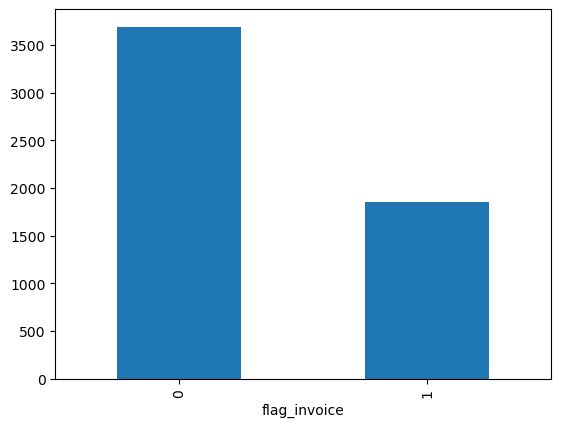

In [14]:
merged_df["flag_invoice"].value_counts().plot(kind ='bar')

In [15]:
merged_df.corr()

,PONumber,total_invoice_quantity,total_invoice_dollars,Freight,days_to_gen_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
total_invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
total_invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_to_gen_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


<Axes: >

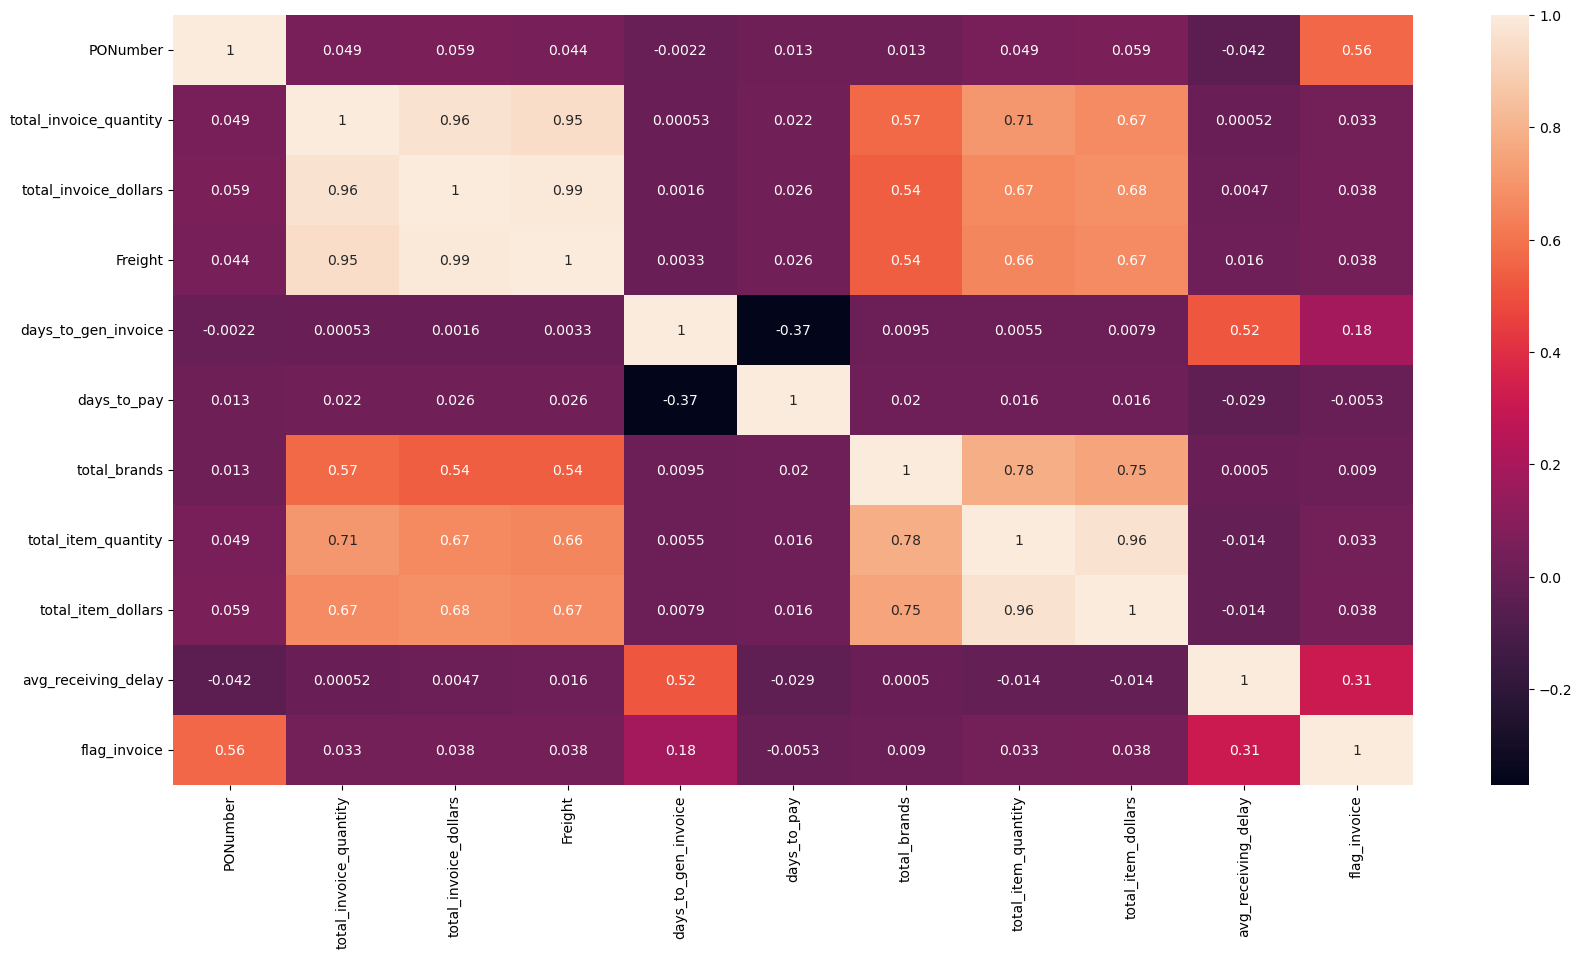

In [16]:
plt.figure(figsize=(20,10))
sns.heatmap(merged_df.corr(), annot=True)


In [17]:
from scipy.stats import ttest_ind


# Numerical columns you want to compare
metrics = [
    'PONumber',
    'total_invoice_quantity',
    'total_invoice_dollars',
    'Freight',
    'days_to_gen_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay',
    'flag_invoice'
]


# Separate invoices into two groups
flagged = merged_df[merged_df["flag_invoice"] == 1]
normal = merged_df[merged_df["flag_invoice"] == 0]


# Containers for the results
significant_features = []
non_significant_features = []
results = []


# Test every numerical metric
for metric in metrics:

    # Calculate the average for both groups
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    # Perform Welch's independent t-test
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    # Check statistical significance
    if p_value < 0.05:
        significant_features.append(metric)

        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "t_statistic": round(t_stat, 3),
            "p_value": round(p_value, 3)
        })

    else:
        non_significant_features.append(metric)


# Convert significant results into a DataFrame
results_df = pd.DataFrame(results)

print("Significant features:")
print(significant_features)

print("\nNon-significant features:")
print(non_significant_features)

print("\nDetailed results:")
display(results_df)

Significant features:
['PONumber', 'total_invoice_quantity', 'total_invoice_dollars', 'Freight', 'days_to_gen_invoice', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay', 'flag_invoice']

Non-significant features:
['days_to_pay', 'total_brands']

Detailed results:


c:\Users\trive\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,metric,flagged_mean,normal_mean,t_statistic,p_value
0,PONumber,12167.11,10249.36,47.313,0.000
1,total_invoice_quantity,6728.28,5723.55,2.304,0.021
2,total_invoice_dollars,65600.61,54302.64,2.652,0.008
3,Freight,334.02,276.89,2.646,0.008
4,days_to_gen_invoice,17.23,16.02,13.753,0.000
5,total_item_quantity,6728.28,5723.55,2.304,0.021
6,total_item_dollars,65600.61,54302.64,2.652,0.008
7,avg_receiving_delay,8.47,7.27,22.295,0.000
8,flag_invoice,1.00,0.00,inf,0.000


In [18]:
merged_df.columns

Index(['PONumber', 'total_invoice_quantity', 'total_invoice_dollars',
       'Freight', 'days_to_gen_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay',
       'flag_invoice'],
      dtype='object')

In [19]:
X =merged_df[['total_invoice_quantity', 'total_invoice_dollars',
       'Freight', 'days_to_pay','total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']]

Y =merged_df['flag_invoice']

In [20]:
X.describe()

,total_invoice_quantity,total_invoice_dollars,Freight,days_to_pay,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.000000,5.543000e+03,5543.000000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,6058.880931,5.807338e+04,295.954301,35.468519,6058.880931,5.807338e+04,7.671541
std,14453.338164,1.402340e+05,713.585093,5.842178,14453.338164,1.402340e+05,1.824496
min,1.000000,4.140000e+00,0.020000,23.000000,1.000000,4.140000e+00,3.000000
25%,83.000000,9.678100e+02,5.020000,31.000000,83.000000,9.678100e+02,6.129178
50%,423.000000,4.765450e+03,24.730000,35.000000,423.000000,4.765450e+03,7.744898
75%,5100.500000,4.458718e+04,229.660000,40.000000,5100.500000,4.458718e+04,9.083804
max,141660.000000,1.660436e+06,8468.220000,48.000000,141660.000000,1.660436e+06,13.000000


In [21]:
Y.describe()

count    5543.000000
mean        0.333754
std         0.471596
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: flag_invoice, dtype: float64

In [22]:
X_train ,X_test ,Y_train, Y_test = train_test_split(X, Y ,test_size=0.2 ,random_state=42)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
model_1 = LogisticRegression()
model_1.fit(X_train_scaled,Y_train)

model_2 = DecisionTreeClassifier(random_state=42)
model_2.fit(X_train_scaled,Y_train)

model_3 = RandomForestClassifier()
model_3.fit(X_train_scaled,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred_1 = model_1.predict(X_test_scaled)

y_pred_2 = model_2.predict(X_test_scaled)

y_pred_3 = model_3.predict(X_test_scaled)


In [26]:
print("\nLogistic Regression Performance:")
print("Accuracy :", round(accuracy_score(Y_test, y_pred_1), 2))
print("Classification Report:")
print(classification_report(Y_test, y_pred_1))

print("\nDecision Tree Classifier Performance:")
print("Accuracy :", round(accuracy_score(Y_test, y_pred_2), 2))
print("Classification Report:")
print(classification_report(Y_test, y_pred_2))

print("\nRandom Forest Classifier Performance:")
print("Accuracy :", round(accuracy_score(Y_test, y_pred_3), 2))
print("Classification Report:")
print(classification_report(Y_test, y_pred_3))


Logistic Regression Performance:
Accuracy : 0.74
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.83       725
           1       0.75      0.39      0.51       384

    accuracy                           0.74      1109
   macro avg       0.75      0.66      0.67      1109
weighted avg       0.75      0.74      0.72      1109


Decision Tree Classifier Performance:
Accuracy : 0.94
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       725
           1       0.92      0.91      0.91       384

    accuracy                           0.94      1109
   macro avg       0.94      0.93      0.93      1109
weighted avg       0.94      0.94      0.94      1109


Random Forest Classifier Performance:
Accuracy : 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
        

In [27]:
print("\nRandom Forest Classifier Performance:")
print("Accuracy :", round(accuracy_score(Y_test, y_pred_3), 2))
print("Classification Report:")
print(classification_report(Y_test, y_pred_3))


Random Forest Classifier Performance:
Accuracy : 0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       725
           1       1.00      0.88      0.93       384

    accuracy                           0.96      1109
   macro avg       0.97      0.94      0.95      1109
weighted avg       0.96      0.96      0.96      1109



In [28]:
import joblib

joblib.dump(model_3,"invoice_model.pkl")

joblib.dump(scaler, "invoice_scaler.pkl")

joblib.dump(list(X.columns), "invoice_columns.pkl")

print("Model saved successfully")

Model saved successfully
